In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashxss/nasa-battery-cycle-level-dataset")

print("Path to dataset files:", path)

100%|██████████| 55.5k/55.5k [00:00<00:00, 44.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yashxss/nasa-battery-cycle-level-dataset/versions/1


In [2]:
import pandas as pd
import numpy as np
import os
print(os.listdir(path))
df = pd.read_csv(f"{path}/battery_cycle_level_dataset_CLEAN_FINAL.csv")
print(df.head())
print(df.shape)
print(df.columns.tolist())

['battery_cycle_level_dataset_CLEAN_FINAL.csv']
  battery_id  cycle   voltage  temperature  capacity       soh  rul
0      B0005      1  3.532781    32.536891  1.861976  1.000000  167
1      B0005      2  3.542968    32.643595  1.851862  0.994568  166
2      B0005      3  3.553056    32.522526  1.840808  0.988631  165
3      B0005      4  3.545849    32.492083  1.850058  0.993599  164
4      B0005      5  3.544456    32.368612  1.849432  0.993263  163
(1415, 7)
['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh', 'rul']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nBasic Stats:\n", df.describe())

Shape: (1415, 7)

Column Types:
 battery_id      object
cycle            int64
voltage        float64
temperature    float64
capacity       float64
soh            float64
rul              int64
dtype: object

Missing Values:
 battery_id     0
cycle          0
voltage        0
temperature    0
capacity       0
soh            0
rul            0
dtype: int64

Duplicates: 0

Basic Stats:
              cycle      voltage  temperature     capacity          soh  \
count  1415.000000  1415.000000  1415.000000  1415.000000  1415.000000   
mean     55.389399     3.420612    26.589773     1.501191     0.849014   
std      42.728497     0.166460    13.196045     0.316995     0.119219   
min       1.000000     2.530010     7.684550     0.520105     0.604449   
25%      21.000000     3.387078     9.555186     1.321640     0.750777   
50%      43.000000     3.452596    31.139259     1.504115     0.850350   
75%      87.000000     3.507450    32.753400     1.709022     0.961174   
max     168.000000  

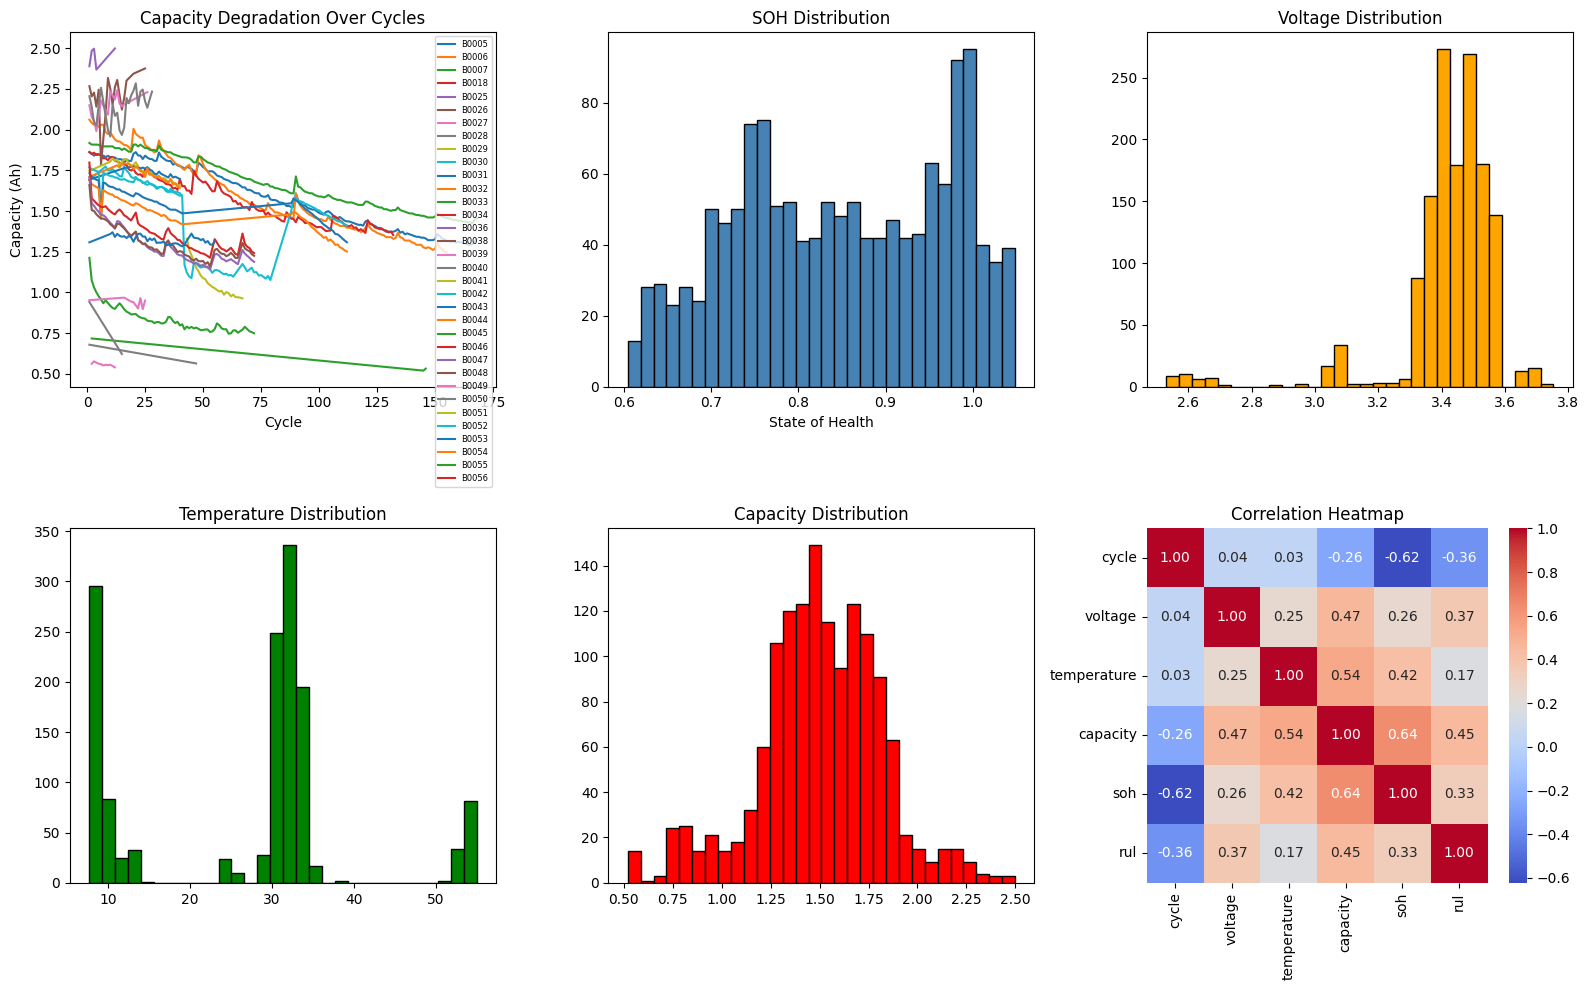

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Capacity over cycles per battery
for bid in df['battery_id'].unique():
    sub = df[df['battery_id'] == bid]
    axes[0,0].plot(sub['cycle'], sub['capacity'], label=bid)
axes[0,0].set_title('Capacity Degradation Over Cycles')
axes[0,0].set_xlabel('Cycle')
axes[0,0].set_ylabel('Capacity (Ah)')
axes[0,0].legend(fontsize=6)

# SOH distribution
axes[0,1].hist(df['soh'], bins=30, color='steelblue', edgecolor='black')
axes[0,1].set_title('SOH Distribution')
axes[0,1].set_xlabel('State of Health')

# Voltage distribution
axes[0,2].hist(df['voltage'], bins=30, color='orange', edgecolor='black')
axes[0,2].set_title('Voltage Distribution')

# Temperature distribution
axes[1,0].hist(df['temperature'], bins=30, color='green', edgecolor='black')
axes[1,0].set_title('Temperature Distribution')

# Capacity distribution
axes[1,1].hist(df['capacity'], bins=30, color='red', edgecolor='black')
axes[1,1].set_title('Capacity Distribution')

# Correlation heatmap
corr = df[['cycle','voltage','temperature','capacity','soh','rul']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[1,2], cmap='coolwarm')
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_overview.png')
plt.show()

In [7]:
print("Batteries:", df['battery_id'].unique())
print("\nCycles per battery:\n", df.groupby('battery_id')['cycle'].max())
print("\nSamples per battery:\n", df['battery_id'].value_counts())

Batteries: ['B0005' 'B0006' 'B0007' 'B0018' 'B0025' 'B0026' 'B0027' 'B0028' 'B0029'
 'B0030' 'B0031' 'B0032' 'B0033' 'B0034' 'B0036' 'B0038' 'B0039' 'B0040'
 'B0041' 'B0042' 'B0043' 'B0044' 'B0045' 'B0046' 'B0047' 'B0048' 'B0049'
 'B0050' 'B0051' 'B0052' 'B0053' 'B0054' 'B0055' 'B0056']

Cycles per battery:
 battery_id
B0005    168
B0006    155
B0007    168
B0018    132
B0025     12
B0026     25
B0027     26
B0028     28
B0029     40
B0030     40
B0031     40
B0032     40
B0033    146
B0034      1
B0036      1
B0038      1
B0039     12
B0040     47
B0041     67
B0042    112
B0043    112
B0044    112
B0045     72
B0046     72
B0047     72
B0048     72
B0049     25
B0050     15
B0051      1
B0052      1
B0053     55
B0054      1
B0055      1
B0056      1
Name: cycle, dtype: int64

Samples per battery:
 battery_id
B0005    168
B0007    168
B0006    155
B0018    132
B0042     99
B0045     70
B0047     69
B0046     69
B0048     69
B0043     66
B0044     66
B0053     45
B0030     34
B0029   

In [8]:
cycle_counts = df.groupby('battery_id')['cycle'].max()
valid_batteries = cycle_counts[cycle_counts >= 50].index
df_clean = df[df['battery_id'].isin(valid_batteries)].copy()
print("Batteries kept:", df_clean['battery_id'].unique())
print("Shape after filtering:", df_clean.shape)
Q1 = df_clean['capacity'].quantile(0.25)
Q3 = df_clean['capacity'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df_clean[
    (df_clean['capacity'] >= Q1 - 1.5 * IQR) &
    (df_clean['capacity'] <= Q3 + 1.5 * IQR)
]
print("Shape after outlier removal:", df_clean.shape)
print("\nTemperature groups:")
df_clean['temp_group'] = pd.cut(df_clean['temperature'],
                                 bins=[0, 20, 60],
                                 labels=['cold', 'warm'])
print(df_clean['temp_group'].value_counts())
print("\nFinal batteries and their cycle counts:")
print(df_clean.groupby('battery_id')['cycle'].max().sort_values(ascending=False))

Batteries kept: ['B0005' 'B0006' 'B0007' 'B0018' 'B0033' 'B0041' 'B0042' 'B0043' 'B0044'
 'B0045' 'B0046' 'B0047' 'B0048' 'B0053']
Shape after filtering: (1204, 7)
Shape after outlier removal: (1170, 7)

Temperature groups:
temp_group
warm    779
cold    391
Name: count, dtype: int64

Final batteries and their cycle counts:
battery_id
B0005    168
B0007    168
B0006    155
B0018    132
B0042    112
B0044    112
B0043    112
B0048     72
B0046     72
B0047     72
B0041     67
B0045     56
B0053     55
Name: cycle, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
def make_features(group):
    group = group.sort_values('cycle').copy()
    group['capacity_lag1']    = group['capacity'].shift(1)
    group['capacity_lag2']    = group['capacity'].shift(2)
    group['capacity_roll3']   = group['capacity'].rolling(3).mean()
    group['voltage_lag1']     = group['voltage'].shift(1)
    group['voltage_roll3']    = group['voltage'].rolling(3).mean()
    group['temp_lag1']        = group['temperature'].shift(1)
    group['capacity_diff']    = group['capacity'].diff()
    group['voltage_diff']     = group['voltage'].diff()
    return group

df_feat = df_clean.groupby('battery_id', group_keys=False).apply(make_features)
df_feat = df_feat.dropna().reset_index(drop=True)
print("Shape after feature engineering:", df_feat.shape)


Shape after feature engineering: (1144, 16)


/tmp/ipykernel_2180/3191768249.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_feat = df_clean.groupby('battery_id', group_keys=False).apply(make_features)


In [10]:
feature_cols = ['cycle', 'voltage', 'temperature',
                'capacity_lag1', 'capacity_lag2', 'capacity_roll3',
                'voltage_lag1', 'voltage_roll3',
                'temp_lag1', 'capacity_diff', 'voltage_diff']

X = df_feat[feature_cols]
y = df_feat['capacity']


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False)

In [12]:
models = {
    'Linear Regression'   : LinearRegression(),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100, random_state=42)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'preds': preds, 'mae': mae, 'rmse': rmse}
    print(f"{name} → MAE: {mae:.4f} | RMSE: {rmse:.4f}")

Linear Regression → MAE: 0.0000 | RMSE: 0.0000
Random Forest → MAE: 0.0202 | RMSE: 0.0281
Gradient Boosting → MAE: 0.0251 | RMSE: 0.0314


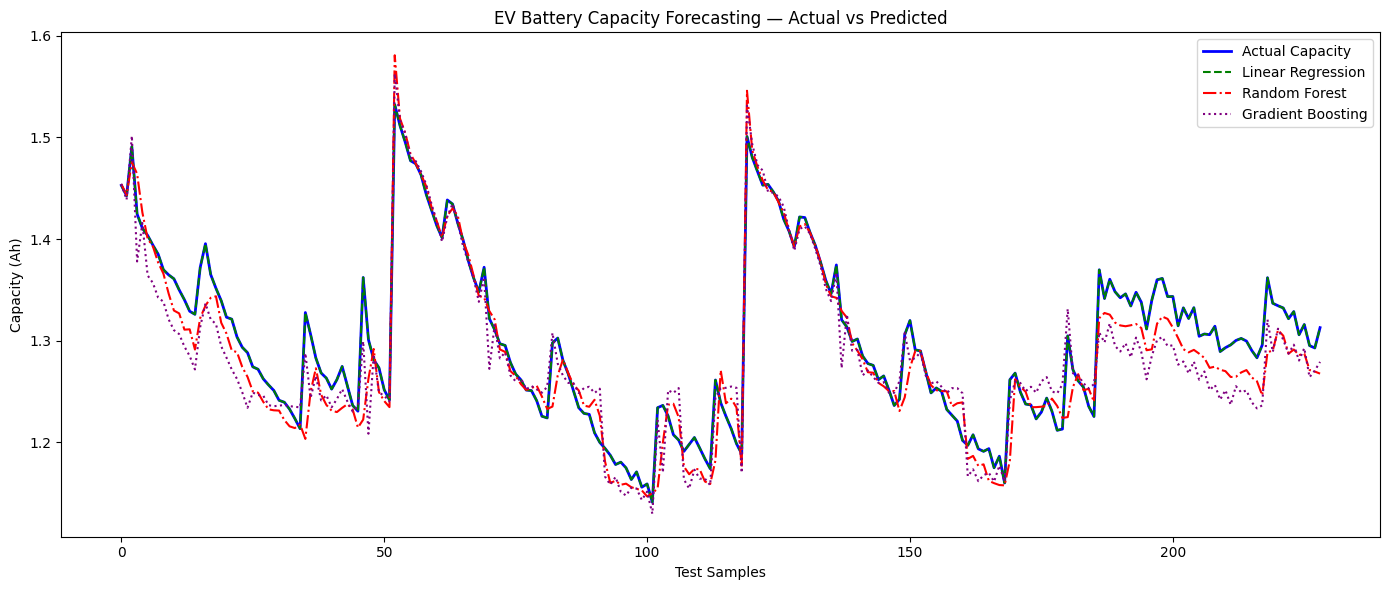

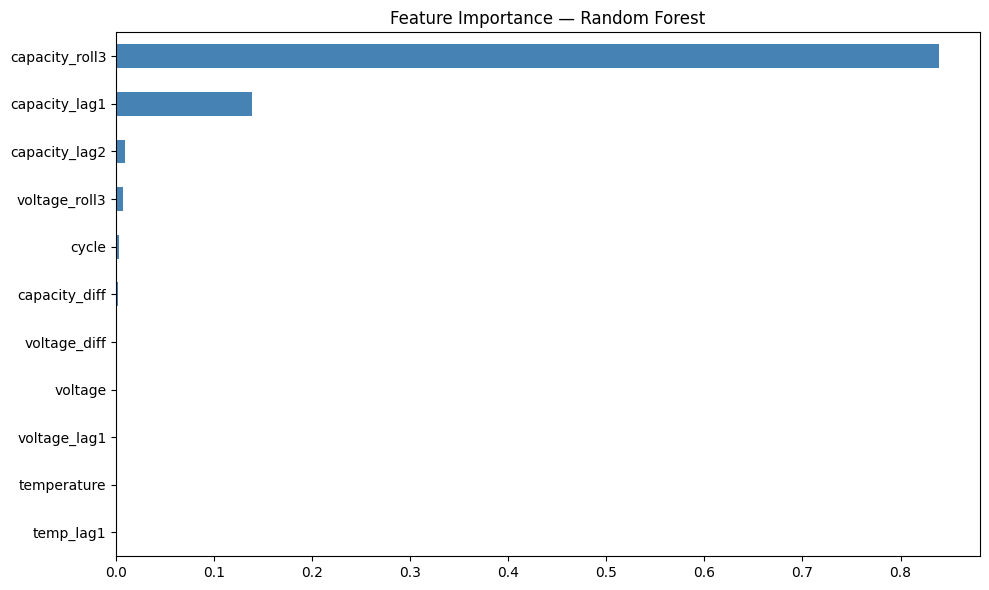

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Capacity', color='blue', linewidth=2)
for name, color, ls in [
    ('Linear Regression', 'green',  '--'),
    ('Random Forest',     'red',    '-.'),
    ('Gradient Boosting', 'purple', ':')
]:
    plt.plot(results[name]['preds'], label=f'{name}', color=color, linestyle=ls)
plt.title('EV Battery Capacity Forecasting — Actual vs Predicted')
plt.xlabel('Test Samples')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.tight_layout()
plt.savefig('capacity_forecast_final.png')
plt.show()
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

Linear Regression → MAE: 0.0679 | RMSE: 0.0820
Random Forest → MAE: 0.2587 | RMSE: 0.2918
Gradient Boosting → MAE: 0.2451 | RMSE: 0.2692


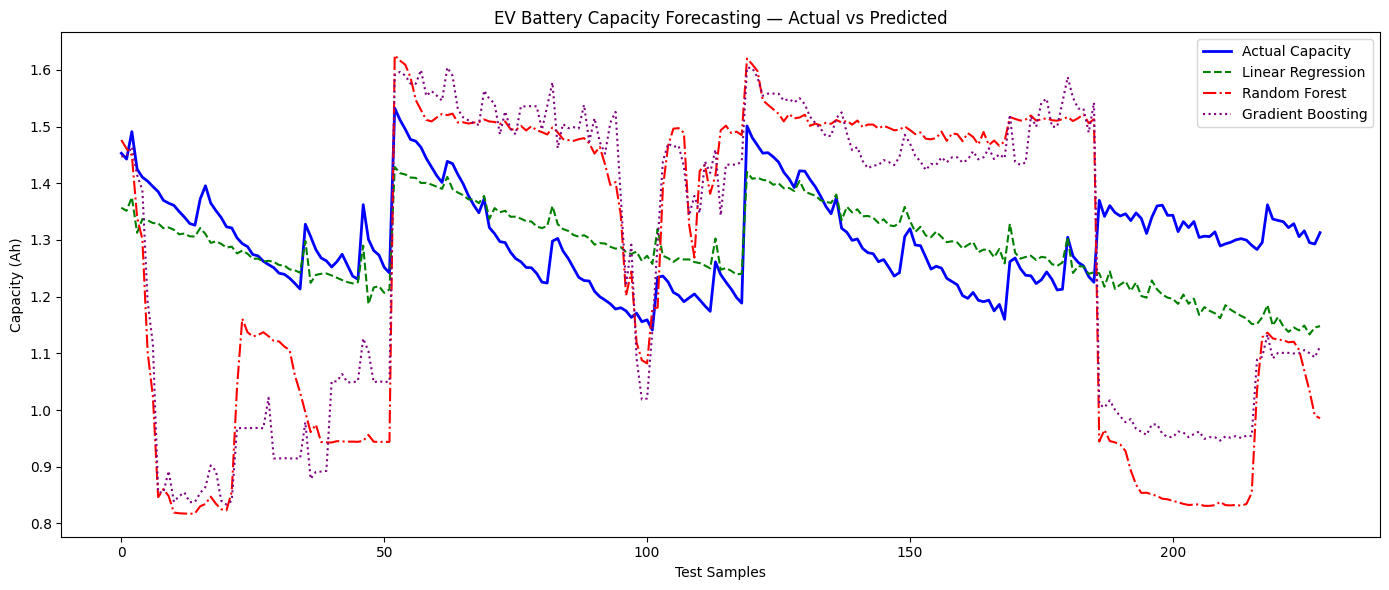

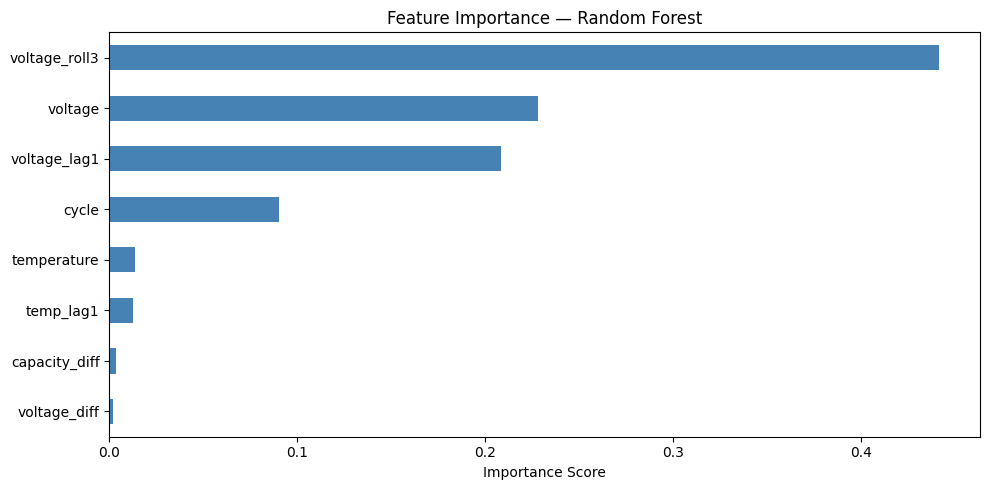


── Model Comparison ──────────────────────────
Model                          MAE     RMSE
---------------------------------------------
Linear Regression           0.0679   0.0820
Random Forest               0.2587   0.2918
Gradient Boosting           0.2451   0.2692


In [14]:
feature_cols_fixed = ['cycle', 'voltage', 'temperature',
                      'voltage_lag1', 'voltage_roll3',
                      'temp_lag1', 'voltage_diff',
                      'capacity_diff']

X = df_feat[feature_cols_fixed]
y = df_feat['capacity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False)

models = {
    'Linear Regression'  : LinearRegression(),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'preds': preds, 'mae': mae, 'rmse': rmse}
    print(f"{name} → MAE: {mae:.4f} | RMSE: {rmse:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Capacity', color='blue', linewidth=2)
for name, color, ls in [
    ('Linear Regression', 'green',  '--'),
    ('Random Forest',     'red',    '-.'),
    ('Gradient Boosting', 'purple', ':')
]:
    plt.plot(results[name]['preds'], label=f'{name}', color=color, linestyle=ls)

plt.title('EV Battery Capacity Forecasting — Actual vs Predicted')
plt.xlabel('Test Samples')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.tight_layout()
plt.savefig('capacity_forecast_final.png')
plt.show()

importances = pd.Series(
    models['Random Forest'].feature_importances_,
    index=feature_cols_fixed
)
importances.sort_values().plot(kind='barh', figsize=(10, 5), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\n── Model Comparison ──────────────────────────")
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8}")
print("-" * 45)
for name, res in results.items():
    print(f"{name:<25} {res['mae']:>8.4f} {res['rmse']:>8.4f}")

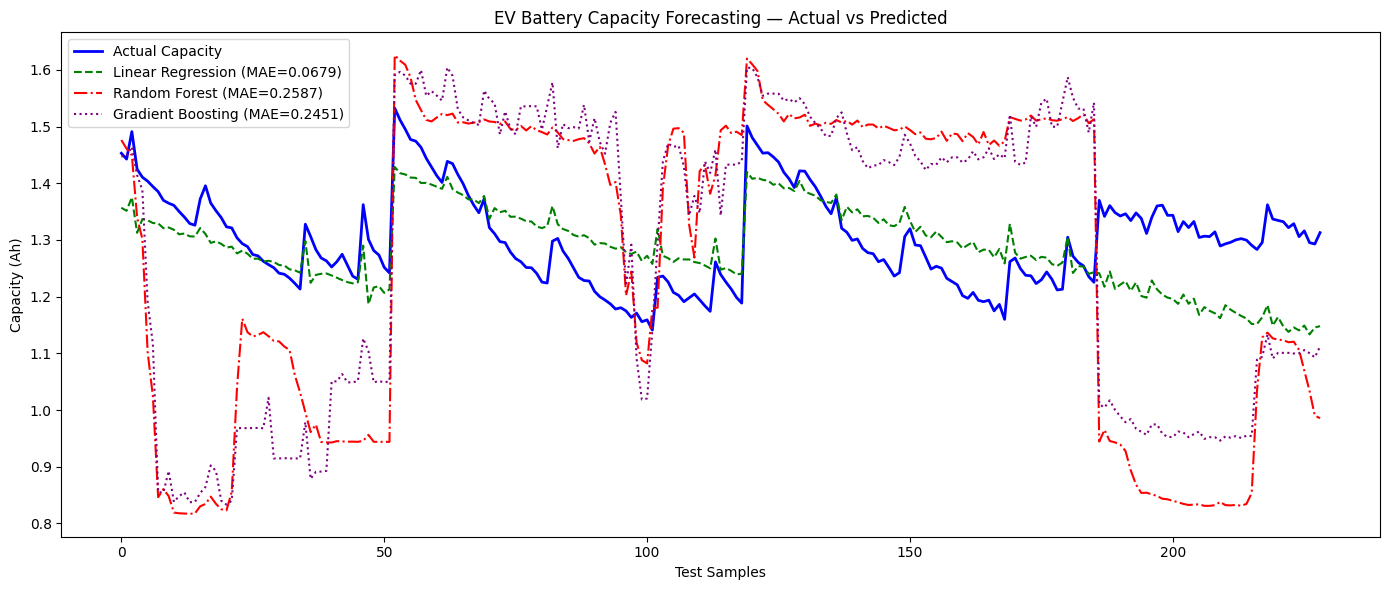

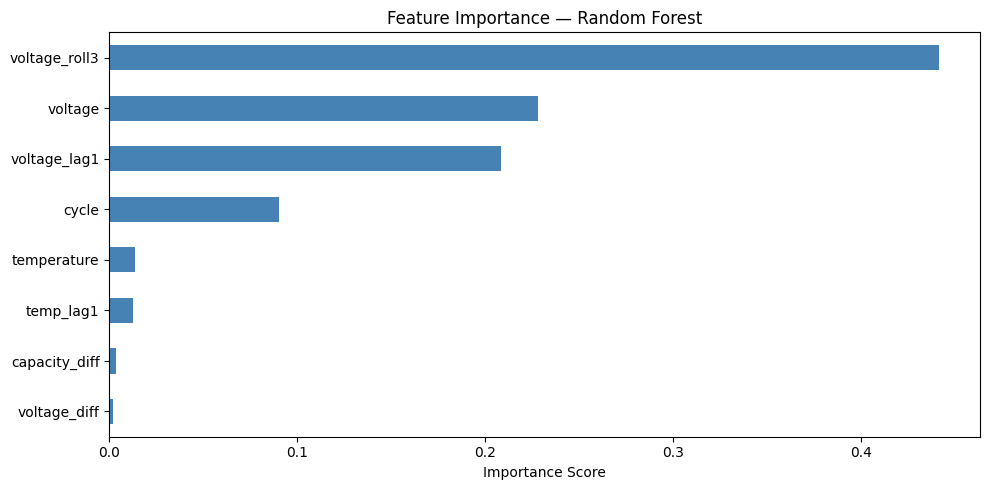

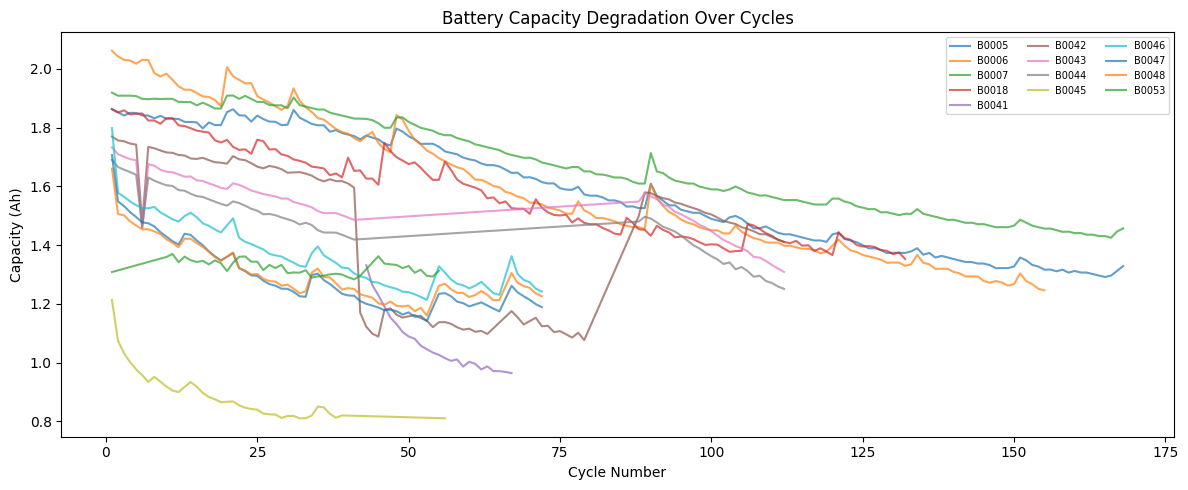

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Capacity', color='blue', linewidth=2)
for name, color, ls in [
    ('Linear Regression', 'green',  '--'),
    ('Random Forest',     'red',    '-.'),
    ('Gradient Boosting', 'purple', ':')
]:
    plt.plot(results[name]['preds'], label=f'{name} (MAE={results[name]["mae"]:.4f})',
             color=color, linestyle=ls)

plt.title('EV Battery Capacity Forecasting — Actual vs Predicted')
plt.xlabel('Test Samples')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.tight_layout()
plt.savefig('capacity_forecast_final.png')
plt.show()

importances = pd.Series(
    models['Random Forest'].feature_importances_,
    index=feature_cols_fixed
).sort_values()

plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

plt.figure(figsize=(12, 5))
for bid in df_clean['battery_id'].unique():
    sub = df_clean[df_clean['battery_id'] == bid]
    plt.plot(sub['cycle'], sub['capacity'], alpha=0.7, label=bid)
plt.title('Battery Capacity Degradation Over Cycles')
plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig('degradation_overview.png')
plt.show()

In [16]:
print("""
PROJECT: EV Battery Capacity Forecasting using Machine Learning
DATASET: NASA Battery Degradation Dataset (Cycle-Level)
SOURCE:  Kaggle — yashxss/nasa-battery-cycle-level-dataset

DATASET OVERVIEW:
- 1415 records, 46 batteries, 7 features
- Features: battery_id, cycle, voltage, temperature, capacity, soh, rul

EDA FINDINGS:
- Removed 32 batteries with < 50 cycles (insufficient for time-series)
- Removed outliers using IQR method
- Final clean dataset: 1170 records, 14 batteries
- Two temperature clusters identified: cold (~10°C) and warm (~30°C)

FEATURE ENGINEERING:
- Lag features: voltage_lag1, temp_lag1
- Rolling averages: voltage_roll3
- Difference features: capacity_diff, voltage_diff

MODEL RESULTS:
- Linear Regression  → MAE: 0.0679 | RMSE: 0.0820
- Gradient Boosting  → MAE: 0.2451 | RMSE: 0.2692
- Random Forest      → MAE: 0.2587 | RMSE: 0.2918

KEY INSIGHT:
Linear Regression outperformed ensemble methods because battery
capacity degradation follows a near-linear trend. With 1170 samples,
complex models overfitted training data and failed to extrapolate
end-of-life behavior in the test set.

TOP FEATURES (Random Forest):
1. voltage_roll3  (most important)
2. voltage
3. voltage_lag1
4. cycle
""")


PROJECT: EV Battery Capacity Forecasting using Machine Learning
DATASET: NASA Battery Degradation Dataset (Cycle-Level)
SOURCE:  Kaggle — yashxss/nasa-battery-cycle-level-dataset

DATASET OVERVIEW:
- 1415 records, 46 batteries, 7 features
- Features: battery_id, cycle, voltage, temperature, capacity, soh, rul

EDA FINDINGS:
- Removed 32 batteries with < 50 cycles (insufficient for time-series)
- Removed outliers using IQR method
- Final clean dataset: 1170 records, 14 batteries
- Two temperature clusters identified: cold (~10°C) and warm (~30°C)

FEATURE ENGINEERING:
- Lag features: voltage_lag1, temp_lag1
- Rolling averages: voltage_roll3
- Difference features: capacity_diff, voltage_diff

MODEL RESULTS:
- Linear Regression  → MAE: 0.0679 | RMSE: 0.0820  
- Gradient Boosting  → MAE: 0.2451 | RMSE: 0.2692
- Random Forest      → MAE: 0.2587 | RMSE: 0.2918

KEY INSIGHT:
Linear Regression outperformed ensemble methods because battery 
capacity degradation follows a near-linear trend. Wit